In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

In [22]:

# =========================================================
# 1) LEER CSV
# =========================================================
pd.set_option("display.max_columns", 300)

df = pd.read_csv("M41_pm_lab2.csv")
print(df.columns.tolist())
df.head()


['source_id', 'ra', 'ra_error', 'dec', 'dec_error', 'parallax', 'parallax_error', 'pm', 'pmra', 'pmra_error', 'pmdec', 'pmdec_error', 'pmra_pmdec_corr', 'ruwe', 'phot_g_mean_flux_error', 'phot_g_mean_flux_over_error', 'phot_g_mean_mag', 'phot_bp_mean_flux_error', 'phot_bp_mean_flux_over_error', 'phot_bp_mean_mag', 'phot_rp_mean_flux_error', 'phot_rp_mean_flux_over_error', 'phot_rp_mean_mag', 'bp_rp', 'radial_velocity', 'has_xp_sampled', 'has_mcmc_msc', 'teff_gspphot', 'ag_gspphot', 'target_id', 'target_ra', 'target_dec', 'target_parallax', 'target_pm_ra', 'target_pm_dec', 'target_radial_velocity', 'epoch', 'target_separation (deg)']


,source_id,ra,ra_error,dec,dec_error,parallax,parallax_error,pm,pmra,pmra_error,pmdec,pmdec_error,pmra_pmdec_corr,ruwe,phot_g_mean_flux_error,phot_g_mean_flux_over_error,phot_g_mean_mag,phot_bp_mean_flux_error,phot_bp_mean_flux_over_error,phot_bp_mean_mag,phot_rp_mean_flux_error,phot_rp_mean_flux_over_error,phot_rp_mean_mag,bp_rp,radial_velocity,has_xp_sampled,has_mcmc_msc,teff_gspphot,ag_gspphot,target_id,target_ra,target_dec,target_parallax,target_pm_ra,target_pm_dec,target_radial_velocity,epoch,target_separation (deg)
0,2927008220678979072,101.521761,0.096065,-20.752418,0.140986,1.640919,0.170961,26.600690,5.300414,0.104096,26.067267,0.163241,0.184431,0.980225,0.754489,715.66650,18.856459,8.184485,13.199410,20.254677,10.391776,61.102460,17.741024,2.513653,NaN,False,False,3325.2085,0.3729,NGC 2287,101.51292,-20.71861,1.36,-4.339,-1.381,23.37,2000,0.034803
1,2927009010952534400,101.480106,0.086071,-20.735266,0.128442,1.563817,0.155893,11.571219,10.625169,0.092550,-4.582456,0.140020,0.179972,1.036867,0.818538,861.29010,18.566896,7.401438,21.252388,19.846733,6.828662,119.738045,17.466476,2.380257,NaN,False,False,3538.9573,0.4270,NGC 2287,101.51292,-20.71861,1.36,-4.339,-1.381,23.37,2000,0.034898
2,2927008534218797184,101.530020,0.012817,-20.754326,0.019033,1.645853,0.025224,3.484469,-3.341236,0.013646,-0.988772,0.022532,0.260350,1.460459,3309.593500,8574.29800,7.054934,3709.832500,4006.481700,7.408248,5425.532000,3653.973000,6.504876,0.903372,5.59619,True,True,NaN,NaN,NGC 2287,101.51292,-20.71861,1.36,-4.339,-1.381,23.37,2000,0.039135
3,2927009530643005440,101.552869,0.333892,-20.701071,0.498013,1.564292,0.672288,5.656420,-5.341174,0.393541,-1.861973,0.612223,0.346404,1.077184,0.612882,236.71964,20.283340,3.895687,9.648706,21.400910,5.508032,33.834408,19.072008,2.328901,NaN,False,False,NaN,NaN,NGC 2287,101.51292,-20.71861,1.36,-4.339,-1.381,23.37,2000,0.041299
4,2927014650244020608,101.566790,0.132918,-20.710013,0.194753,1.627883,0.252674,4.172075,-4.070057,0.147054,-0.916977,0.213176,0.147653,1.026092,0.720094,518.65380,19.256700,4.869026,16.239480,20.593506,6.246095,69.760120,18.149857,2.443649,NaN,False,False,NaN,NaN,NGC 2287,101.51292,-20.71861,1.36,-4.339,-1.381,23.37,2000,0.051135


In [23]:
df_alt = df[["phot_bp_mean_mag","phot_rp_mean_mag","bp_rp"]].copy()
df_alt["diff"] = df_alt["phot_bp_mean_mag"] - df_alt["phot_rp_mean_mag"]
df_alt.head()

,phot_bp_mean_mag,phot_rp_mean_mag,bp_rp,diff
0,20.254677,17.741024,2.513653,2.513653
1,19.846733,17.466476,2.380257,2.380257
2,7.408248,6.504876,0.903372,0.903372
3,21.400910,19.072008,2.328901,2.328902
4,20.593506,18.149857,2.443649,2.443649


In [24]:

df = df.dropna(subset=["pmra", "pmdec", "phot_g_mean_mag", "bp_rp"]).copy()

mu_x = df["pmra"].values
mu_y = df["pmdec"].values
G = df["phot_g_mean_mag"].values
color = df["bp_rp"].values

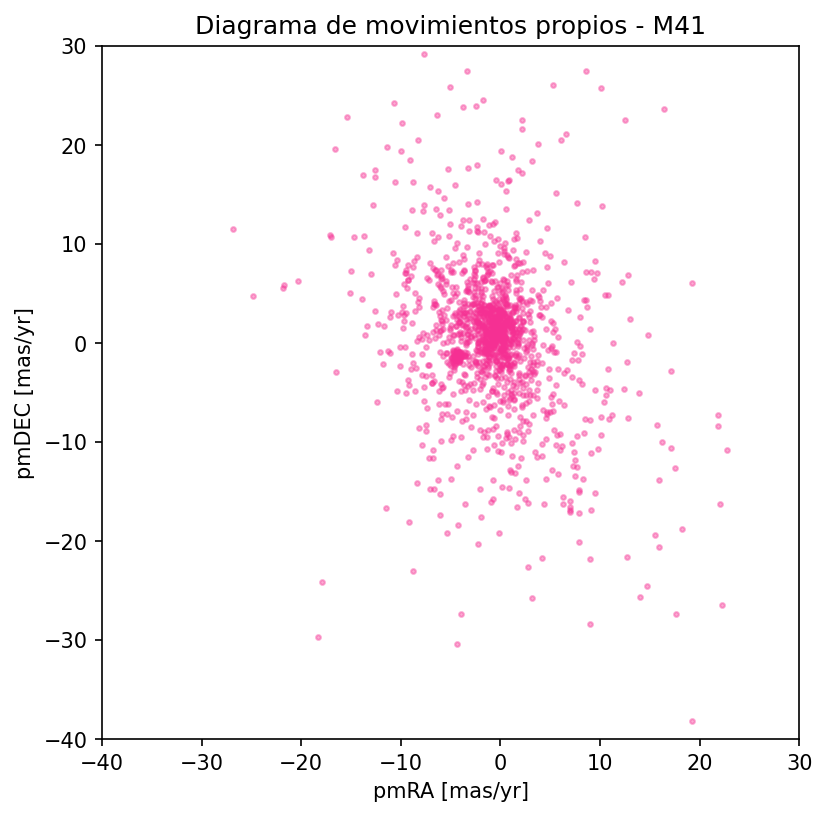

In [25]:
plt.figure(figsize=(6,6), dpi=150)
plt.scatter(mu_x, mu_y, s=5, alpha=0.4, color="#F53093")
plt.xlabel("pmRA [mas/yr]")
plt.xlim(-40,30)
plt.ylabel("pmDEC [mas/yr]")
plt.ylim(-40,30)
plt.title("Diagrama de movimientos propios - M41")
plt.show()

C:\Users\Petya_\AppData\Local\Temp\ipykernel_37200\284124301.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


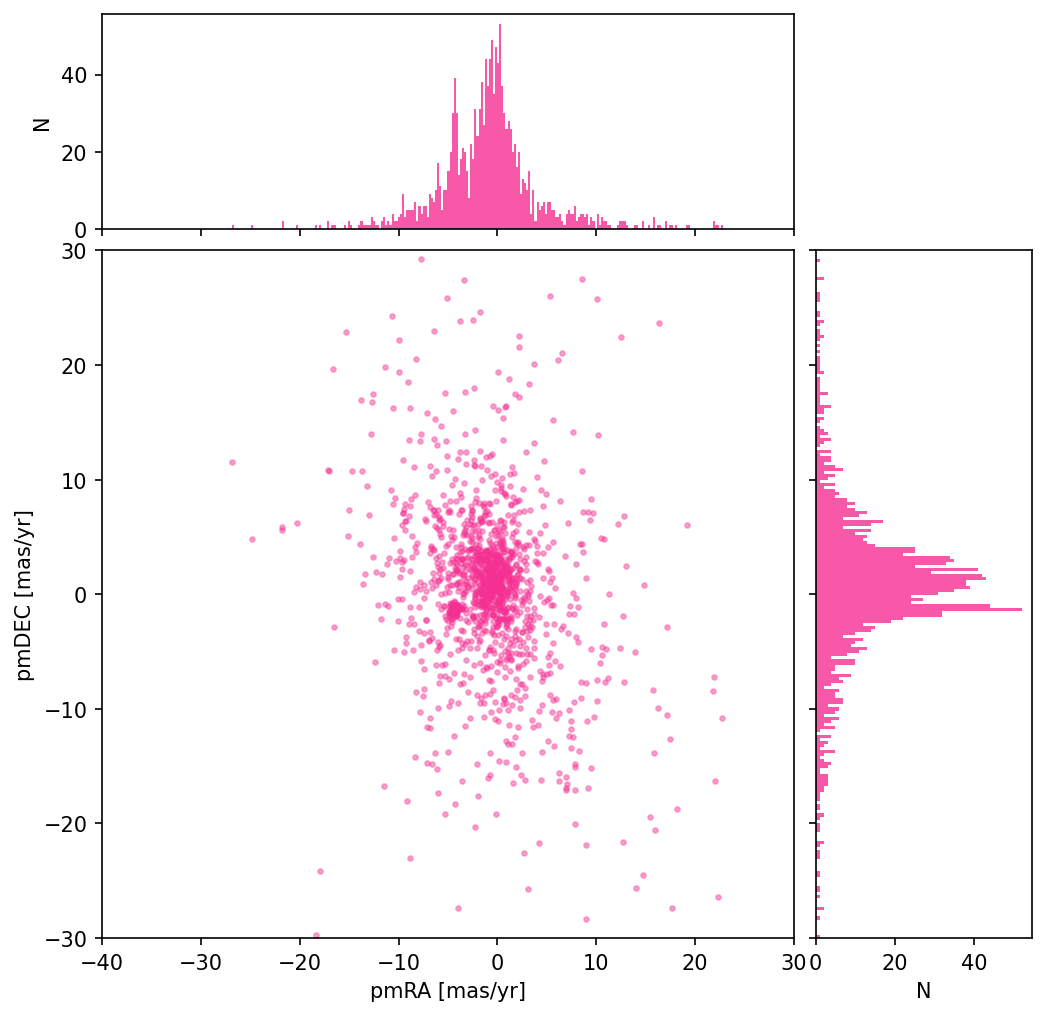

In [26]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(8,8), dpi=150)
gs = GridSpec(4, 4, figure=fig, hspace=0.1, wspace=0.1)

ax_scatter = fig.add_subplot(gs[1:4, 0:3])
ax_histx   = fig.add_subplot(gs[0, 0:3], sharex=ax_scatter)
ax_histy   = fig.add_subplot(gs[1:4, 3], sharey=ax_scatter)

# scatter principal
ax_scatter.scatter(mu_x, mu_y, s=5, alpha=0.4, color="#F53093")
ax_scatter.set_xlabel("pmRA [mas/yr]")
ax_scatter.set_ylabel("pmDEC [mas/yr]")
ax_scatter.set_xlim(-40, 30)
ax_scatter.set_ylim(-30, 30)

# histograma superior (pmRA)
ax_histx.hist(mu_x, bins=500, color="#F53093", alpha=0.8)
ax_histx.set_ylabel("N")
ax_histx.tick_params(axis="x", labelbottom=False)

# histograma derecho (pmDEC)
ax_histy.hist(mu_y, bins=600, orientation="horizontal", color="#F53093", alpha=0.8)
ax_histy.set_xlabel("N")
ax_histy.tick_params(axis="y", labelleft=False)
fig.tight_layout()
plt.show()

In [27]:


# =========================================================
# 2) VALORES INICIALES
# La tesis usa nf=0.5 y obtiene iniciales desde histogramas.
# Aquí hacemos una aproximación robusta para arrancar el LM.
# =========================================================
# pico del histograma como centro inicial del cúmulo
hist_x, edges_x = np.histogram(mu_x, bins=60)
hist_y, edges_y = np.histogram(mu_y, bins=60)
cx = 0.5 * (edges_x[:-1] + edges_x[1:])
cy = 0.5 * (edges_y[:-1] + edges_y[1:])

# =========================================================
# Picos principales.
# =========================================================

mu_xc0 = cx[np.argmax(hist_x)]
mu_yc0 = cy[np.argmax(hist_y)]

print("Pico mu_x =", mu_xc0)
print("Pico mu_y =", mu_yc0)

# radio inicial para separar una zona probable del cúmulo
r0 = 2.5
mask_c0 = ((mu_x - mu_xc0)**2 + (mu_y - mu_yc0)**2) < r0**2

# si sale muy poco, relajamos
if mask_c0.sum() < 20:
    r0 = 4.0
    mask_c0 = ((mu_x - mu_xc0)**2 + (mu_y - mu_yc0)**2) < r0**2

mask_f0 = ~mask_c0

# =========================================================
# dispersión global
# =========================================================

sigma_mux = np.std(mu_x)
sigma_muy = np.std(mu_y)

print("sigma(mu_x) =", sigma_mux)
print("sigma(mu_y) =", sigma_muy)

# parámetros iniciales
sigma0 = np.sqrt((np.var(mu_x[mask_c0]) + np.var(mu_y[mask_c0])) / 2)
sigma0 = max(sigma0, 0.2)

sigma_x0 = max(np.std(mu_x[mask_f0]), 0.5)
sigma_y0 = max(np.std(mu_y[mask_f0]), 0.5)

mu_xf0 = np.mean(mu_x[mask_f0])
mu_yf0 = np.mean(mu_y[mask_f0])

rho0 = np.corrcoef(mu_x[mask_f0], mu_y[mask_f0])[0, 1]
if not np.isfinite(rho0):
    rho0 = 0.0
rho0 = np.clip(rho0, -0.8, 0.8)

nf0 = np.clip(mask_f0.mean(), 0.1, 0.9)

theta0 = np.array([
    mu_xf0, mu_yf0, sigma_x0, sigma_y0,
    mu_xc0, mu_yc0, sigma0, nf0, rho0
], dtype=float)

print("Valores iniciales:")
print(f"mu_xf0={mu_xf0:.4f}, mu_yf0={mu_yf0:.4f}")
print(f"sigma_x0={sigma_x0:.4f}, sigma_y0={sigma_y0:.4f}")
print(f"mu_xc0={mu_xc0:.4f}, mu_yc0={mu_yc0:.4f}")
print(f"sigma0={sigma0:.4f}, nf0={nf0:.4f}, rho0={rho0:.4f}")

Pico mu_x = 0.22282263209454278
Pico mu_y = 1.4871218747646537
sigma(mu_x) = 5.820527910290375
sigma(mu_y) = 8.088957330640529
Valores iniciales:
mu_xf0=-1.0241, mu_yf0=-0.0249
sigma_x0=6.7293, sigma_y0=9.3544
mu_xc0=0.2228, mu_yc0=1.4871
sigma0=1.0809, nf0=0.7393, rho0=-0.3478


In [28]:

# =========================================================
# 3) ECUACIONES DEL MODELO
# Basadas en la tesis: cluster circular + campo elíptico
# =========================================================
def psi_cluster(mx, my, mu_xc, mu_yc, sigma):
    sigma = max(sigma, 1e-6)
    return (1.0 / (2.0 * np.pi * sigma**2)) * np.exp(
        -0.5 * (((mx - mu_xc)/sigma)**2 + ((my - mu_yc)/sigma)**2)
    )

def psi_field(mx, my, mu_xf, mu_yf, sigma_x, sigma_y, rho):
    sigma_x = max(sigma_x, 1e-6)
    sigma_y = max(sigma_y, 1e-6)
    rho = np.clip(rho, -0.999, 0.999)

    Omega = (
        ((mx - mu_xf)/sigma_x)**2
        + ((my - mu_yf)/sigma_y)**2
        - 2.0 * rho * ((mx - mu_xf)/sigma_x) * ((my - mu_yf)/sigma_y)
    )

    norm = 1.0 / (2.0 * np.pi * sigma_x * sigma_y * np.sqrt(1.0 - rho**2))
    return norm * np.exp(-Omega / (2.0 * (1.0 - rho**2)))

def residuals_mle(theta, mx, my):
    """
    Residuos de las 9 ecuaciones de máxima verosimilitud
    para resolver con Levenberg–Marquardt.
    Orden:
    [mu_xf, mu_yf, sigma_x, sigma_y, mu_xc, mu_yc, sigma, nf, rho]
    """
    mu_xf, mu_yf, sigma_x, sigma_y, mu_xc, mu_yc, sigma, nf, rho = theta

    # restricciones suaves
    sigma_x = max(sigma_x, 1e-6)
    sigma_y = max(sigma_y, 1e-6)
    sigma   = max(sigma,   1e-6)
    nf = np.clip(nf, 1e-6, 1-1e-6)
    rho = np.clip(rho, -0.999, 0.999)

    nc = 1.0 - nf

    # términos de la tesis
    Ci = ((mx - mu_xf)/sigma_x)**2 + ((my - mu_yf)/sigma_y)**2
    Ai = np.exp(-Ci/(2.0*(1.0-rho**2))) * np.exp(
        (rho*(mx-mu_xf)*(my-mu_yf)/(sigma_x*sigma_y)) / (1.0-rho**2)
    )
    Bi = np.exp(
        -0.5 * (((mx - mu_xc)/sigma)**2 + ((my - mu_yc)/sigma)**2)
    )

    psi_i = nc * (Bi / (2.0*np.pi*sigma**2)) + nf * (
        Ai / (2.0*np.pi*sigma_x*sigma_y*np.sqrt(1.0-rho**2))
    )

    psi_inv = 1.0 / np.maximum(psi_i, 1e-300)

    # ecuaciones 3-16 a 3-24 de la tesis
    r1 = np.sum(
        (nf/(2.0*np.pi*sigma_x*sigma_y*np.sqrt(1.0-rho**2))) *
        psi_inv * Ai *
        (((mx-mu_xf)/(sigma_x**2*(1.0-rho**2))) -
         (rho*(my-mu_yf)/(sigma_x*sigma_y*(1.0-rho**2))))
    )

    r2 = np.sum(
        (nf/(2.0*np.pi*sigma_x*sigma_y*np.sqrt(1.0-rho**2))) *
        psi_inv * Ai *
        (((my-mu_yf)/(sigma_y**2*(1.0-rho**2))) -
         (rho*(mx-mu_xf)/(sigma_x*sigma_y*(1.0-rho**2))))
    )

    r3 = np.sum(
        (nf/(2.0*np.pi*(sigma_x**2)*sigma_y*(1.0-rho**2)**1.5)) *
        psi_inv * Ai *
        (((mx-mu_xf)/sigma_x)**2 -
         rho*(mx-mu_xf)*(my-mu_yf)/(sigma_x*sigma_y) - 1.0)
    )

    r4 = np.sum(
        (nf/(2.0*np.pi*(sigma_y**2)*sigma_x*(1.0-rho**2)**1.5)) *
        psi_inv * Ai *
        (((my-mu_yf)/sigma_y)**2 -
         rho*(mx-mu_xf)*(my-mu_yf)/(sigma_x*sigma_y) - 1.0)
    )

    r5 = np.sum(
        ((1.0-nf)/(2.0*np.pi*sigma**4)) *
        psi_inv * Bi * (mx - mu_xc)
    )

    r6 = np.sum(
        ((1.0-nf)/(2.0*np.pi*sigma**4)) *
        psi_inv * Bi * (my - mu_yc)
    )

    r7 = np.sum(
        ((1.0-nf)/(2.0*np.pi*sigma**3)) *
        psi_inv * Bi *
        ((((mx-mu_xc)/sigma)**2 + ((my-mu_yc)/sigma)**2) - 2.0)
    )

    r8 = np.sum(
        psi_inv * (
            Ai/(2.0*np.pi*sigma_x*sigma_y*np.sqrt(1.0-rho**2))
            - Bi/(2.0*np.pi*sigma**2)
        )
    )

    r9 = np.sum(
        (nf/(2.0*np.pi*sigma_x*sigma_y*(1.0-rho**2)**1.5)) *
        psi_inv * Ai *
        (
            rho
            + ((1.0+rho**2)*(mx-mu_xf)*(my-mu_yf)/(sigma_x*sigma_y*(1.0-rho**2)))
            - (rho*Ci/(1.0-rho**2))
        )
    )

    return np.array([r1, r2, r3, r4, r5, r6, r7, r8, r9], dtype=float)

In [29]:


# =========================================================
# 4) AJUSTE CON LEVENBERG–MARQUARDT
# =========================================================
res = least_squares(
    residuals_mle,
    theta0,
    args=(mu_x, mu_y),
    method="lm",
    max_nfev=5000
)

theta_hat = res.x
mu_xf, mu_yf, sigma_x, sigma_y, mu_xc, mu_yc, sigma, nf, rho = theta_hat
nf = np.clip(nf, 1e-6, 1-1e-6)
nc = 1.0 - nf
rho = np.clip(rho, -0.999, 0.999)

print("\nParámetros finales (MLE + LM):")
print(f"mu_xf = {mu_xf:.6f}")
print(f"mu_yf = {mu_yf:.6f}")
print(f"sigma_x = {sigma_x:.6f}")
print(f"sigma_y = {sigma_y:.6f}")
print(f"mu_xc = {mu_xc:.6f}")
print(f"mu_yc = {mu_yc:.6f}")
print(f"sigma = {sigma:.6f}")
print(f"nf = {nf:.6f}")
print(f"nc = {nc:.6f}")
print(f"rho = {rho:.6f}")
print(f"Convergió: {res.success}, mensaje: {res.message}")



Parámetros finales (MLE + LM):
mu_xf = -0.265377
mu_yf = -0.507825
sigma_x = 7.972028
sigma_y = 11.296565
mu_xc = -1.180929
mu_yc = 0.961625
sigma = 2.532709
nf = 0.418303
nc = 0.581697
rho = -0.333900
Convergió: True, mensaje: `xtol` termination condition is satisfied.


In [30]:
# =========================================================
# 5) PROBABILIDAD DE PERTENENCIA
# =========================================================
psi_c = psi_cluster(mu_x, mu_y, mu_xc, mu_yc, sigma)
psi_f = psi_field(mu_x, mu_y, mu_xf, mu_yf, sigma_x, sigma_y, rho)

P = (nc * psi_c) / np.maximum(nf * psi_f + nc * psi_c, 1e-300)

df["P_member"] = P
df["is_member"] = df["P_member"] >= 0.5

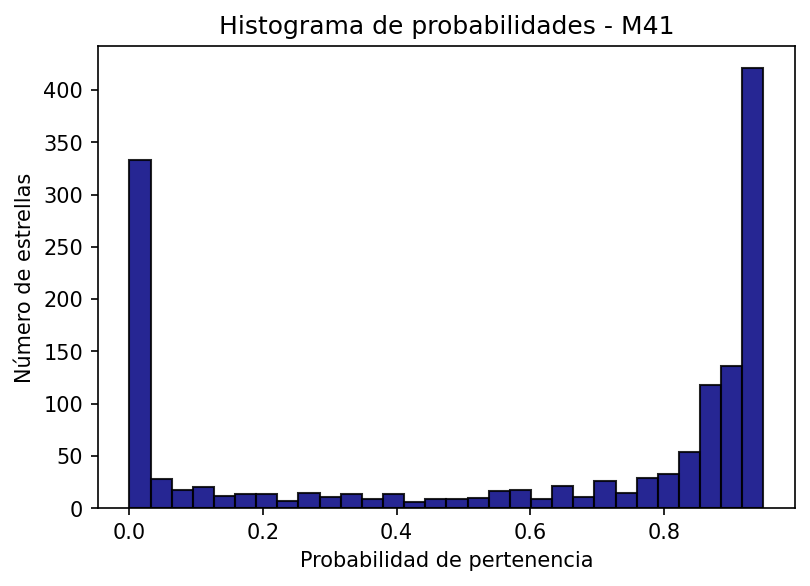

In [31]:
# =========================================================
# 6) HISTOGRAMA DE PROBABILIDADES
# =========================================================
plt.figure(figsize=(6,4), dpi=150)
plt.hist(df["P_member"], bins=30, color="navy", edgecolor="black", alpha=0.85)
plt.xlabel("Probabilidad de pertenencia")
plt.ylabel("Número de estrellas")
plt.title("Histograma de probabilidades - M41")
plt.show()


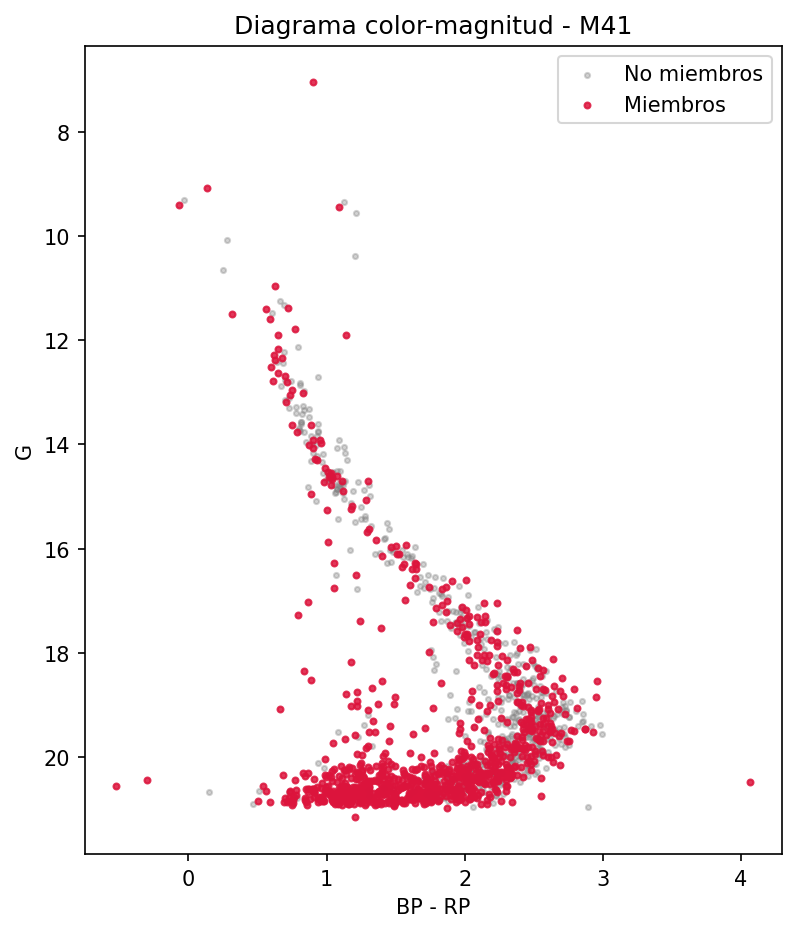

In [32]:
# =========================================================
# 7) CMD
# =========================================================
plt.figure(figsize=(6,7), dpi=150)

plt.scatter(
    df.loc[~df["is_member"], "bp_rp"],
    df.loc[~df["is_member"], "phot_g_mean_mag"],
    s=6, c="gray", alpha=0.35, label="No miembros"
)

plt.scatter(
    df.loc[df["is_member"], "bp_rp"],
    df.loc[df["is_member"], "phot_g_mean_mag"],
    s=8, c="crimson", alpha=0.85, label="Miembros"
)

plt.gca().invert_yaxis()
plt.xlabel("BP - RP")
plt.ylabel("G")
plt.title("Diagrama color-magnitud - M41")
plt.legend()
plt.show()


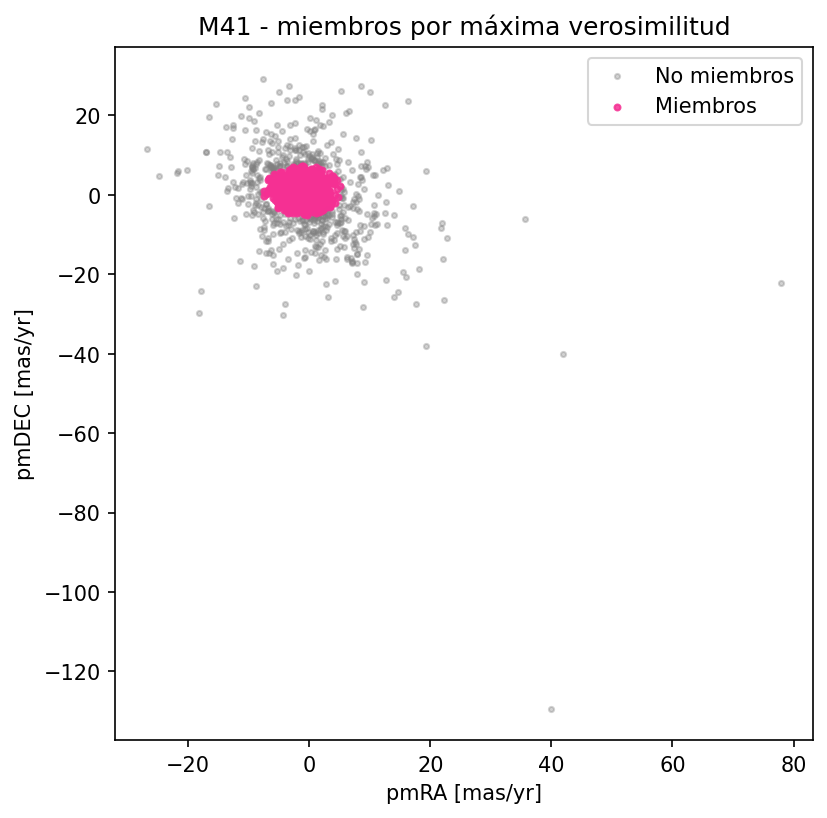

In [33]:
# =========================================================
# 8) DVP COLOREADO
# =========================================================
plt.figure(figsize=(6,6), dpi=150)
plt.scatter(
    df.loc[~df["is_member"], "pmra"],
    df.loc[~df["is_member"], "pmdec"],
    s=6, c="gray", alpha=0.35, label="No miembros"
)
plt.scatter(
    df.loc[df["is_member"], "pmra"],
    df.loc[df["is_member"], "pmdec"],
    s=8, color="#F53093", alpha=0.85, label="Miembros"
)
plt.xlabel("pmRA [mas/yr]")
plt.ylabel("pmDEC [mas/yr]")
plt.title("M41 - miembros por máxima verosimilitud")
plt.legend()
plt.show()

In [34]:
# =========================================================
# 9) RESUMEN
# =========================================================
print("\nResumen:")
print(f"Total estrellas: {len(df)}")
print(f"Miembros (P >= 0.5): {df['is_member'].sum()}")
print(f"No miembros: {(~df['is_member']).sum()}")


Resumen:
Total estrellas: 1442
Miembros (P >= 0.5): 915
No miembros: 527
